In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, 
                             classification_report, mean_squared_error, r2_score)
import warnings
warnings.filterwarnings('ignore')

print("Bibliothèques importées")

Bibliothèques importées


In [2]:
df = pd.read_csv('../data/processed/dataset_clean.csv')
print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
df.head()

Shape : (7174, 11)
Colonnes : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte', 'Source_encoded', 'Categorie_encoded']


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte,Source_encoded,Categorie_encoded
0,-0.814079,-0.557162,-0.518322,-0.030673,-1.584895,0.835439,Papier,Collecte_Citoyenne,Lot de papier récupéré dans un site non rensei...,1,1.0
1,-0.379629,-0.602404,-0.518322,9.577209,-0.937845,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid...",2,2.0
2,-0.583187,-0.752826,-0.518322,-0.145904,-0.614319,3.295478,Plastique,Usine_B,Déchet plastique collecté à l'Usine B. Poids 3...,3,2.0
3,1.616943,1.830616,-0.518322,-0.206337,0.679782,5.632800,Verre,Collecte_Citoyenne,Déchets en verre identifiés lors d'une collect...,1,3.0
4,0.826844,0.758507,-0.518322,-0.206591,1.003307,3.965015,Verre,Collecte_Citoyenne,Déchets en verre identifiés via la collecte ci...,1,3.0


In [3]:
# Garder seulement les lignes avec Categorie connue
df_ml = df[df['Categorie'].notna()].copy()
print(f"Lignes avec labels : {len(df_ml)}")

# Features et cible
features = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source_encoded']
X = df_ml[features]
y = df_ml['Categorie']

print(f"X shape : {X.shape}")
print(f"Distribution cible :\n{y.value_counts()}")

Lignes avec labels : 6791
X shape : (6791, 6)
Distribution cible :
Categorie
Plastique    1912
Verre        1864
Papier       1574
Métal        1441
Name: count, dtype: int64


In [4]:
# Split train / temp (70 / 30)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Split temp → val / test (50 / 50)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val   : {X_val.shape[0]} lignes ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.1f}%)")

Train : 4753 lignes (70.0%)
Val   : 1019 lignes (15.0%)
Test  : 1019 lignes (15.0%)


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

modeles = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

resultats = {}
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    resultats[nom] = {'Accuracy': acc, 'F1-Score': f1}
    print(f"{nom:25s} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

Logistic Regression       → Accuracy: 0.9686 | F1: 0.9686
Random Forest             → Accuracy: 1.0000 | F1: 1.0000
Gradient Boosting         → Accuracy: 1.0000 | F1: 1.0000
SVM                       → Accuracy: 0.9784 | F1: 0.9784
KNN                       → Accuracy: 0.9971 | F1: 0.9971
Decision Tree             → Accuracy: 1.0000 | F1: 1.0000


                     Accuracy  F1-Score
Random Forest          1.0000    1.0000
Gradient Boosting      1.0000    1.0000
Decision Tree          1.0000    1.0000
KNN                    0.9971    0.9971
SVM                    0.9784    0.9784
Logistic Regression    0.9686    0.9686


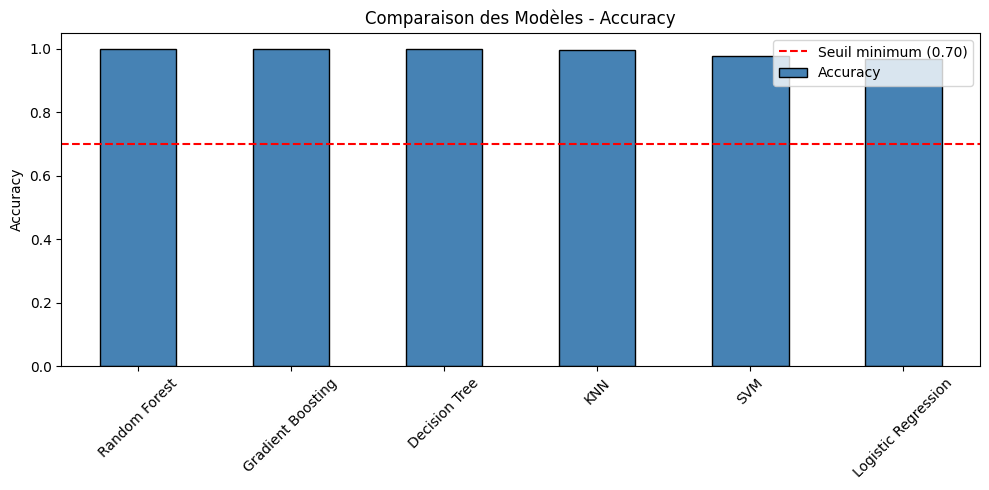

In [6]:
df_resultats = pd.DataFrame(resultats).T.sort_values('Accuracy', ascending=False)
print(df_resultats.round(4))

plt.figure(figsize=(10,5))
df_resultats['Accuracy'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Comparaison des Modèles - Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.axhline(y=0.70, color='red', linestyle='--', label='Seuil minimum (0.70)')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Tester le meilleur modèle sur les données TEST (jamais vues)
meilleur_modele = modeles['Random Forest']

y_pred_test = meilleur_modele.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test, average='weighted')

print(f"=== RESULTAT SUR TEST SET ===")
print(f"Accuracy : {acc_test:.4f}")
print(f"F1-Score : {f1_test:.4f}")
print(f"\n=== RAPPORT CLASSIFICATION ===")
print(classification_report(y_test, y_pred_test))

=== RESULTAT SUR TEST SET ===
Accuracy : 1.0000
F1-Score : 1.0000

=== RAPPORT CLASSIFICATION ===
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       217
      Papier       1.00      1.00      1.00       236
   Plastique       1.00      1.00      1.00       287
       Verre       1.00      1.00      1.00       279

    accuracy                           1.00      1019
   macro avg       1.00      1.00      1.00      1019
weighted avg       1.00      1.00      1.00      1019



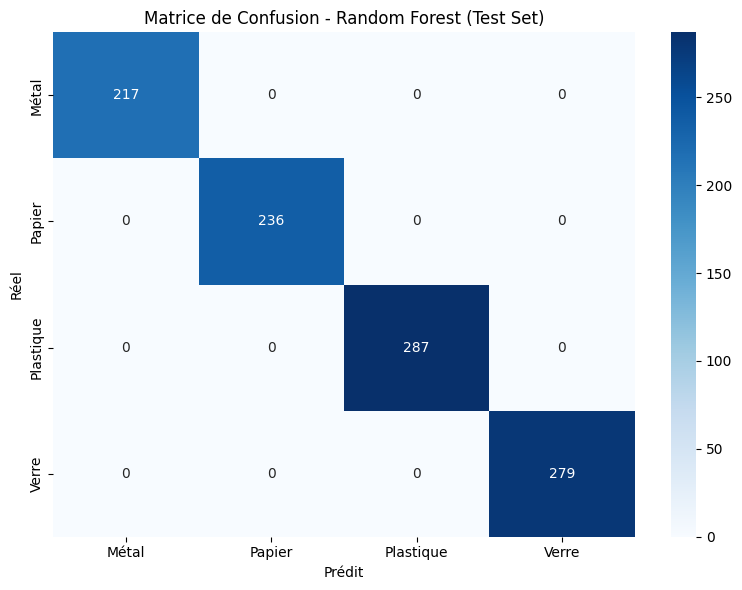

In [8]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=meilleur_modele.classes_,
            yticklabels=meilleur_modele.classes_)
plt.title('Matrice de Confusion - Random Forest (Test Set)')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

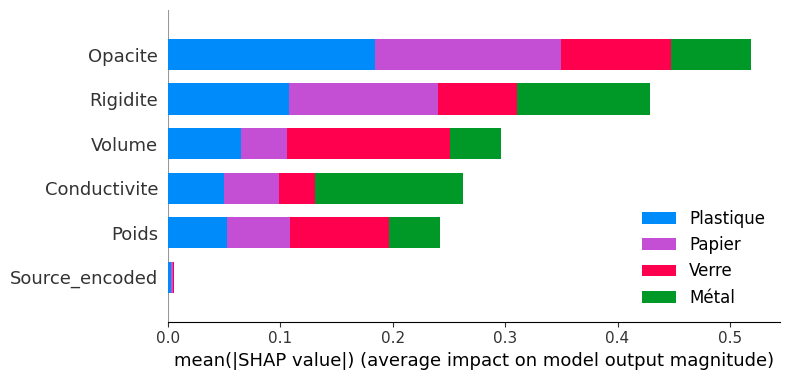

In [9]:
import shap

explainer = shap.TreeExplainer(meilleur_modele)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test,
                  feature_names=features,
                  class_names=meilleur_modele.classes_,
                  plot_type='bar',
                  show=True)

In [11]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Préparer données
X_reg = df_ml[features]
y_reg = df_ml['Prix_Revente']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

# Plusieurs modèles
modeles_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}

resultats_reg = {}
for nom, modele in modeles_reg.items():
    modele.fit(X_train_r, y_train_r)
    y_pred = modele.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2 = r2_score(y_test_r, y_pred)
    resultats_reg[nom] = {'RMSE': rmse, 'R2': r2}
    print(f"{nom:25s} → RMSE: {rmse:.4f} | R²: {r2:.4f}")

Linear Regression         → RMSE: 1.9004 | R²: 0.9017
Ridge                     → RMSE: 1.9004 | R²: 0.9017
Random Forest             → RMSE: 0.0459 | R²: 0.9999
Gradient Boosting         → RMSE: 0.1194 | R²: 0.9996
SVR                       → RMSE: 0.4854 | R²: 0.9936


                     RMSE      R2
Random Forest      0.0459  0.9999
Gradient Boosting  0.1194  0.9996
SVR                0.4854  0.9936
Ridge              1.9004  0.9017
Linear Regression  1.9004  0.9017


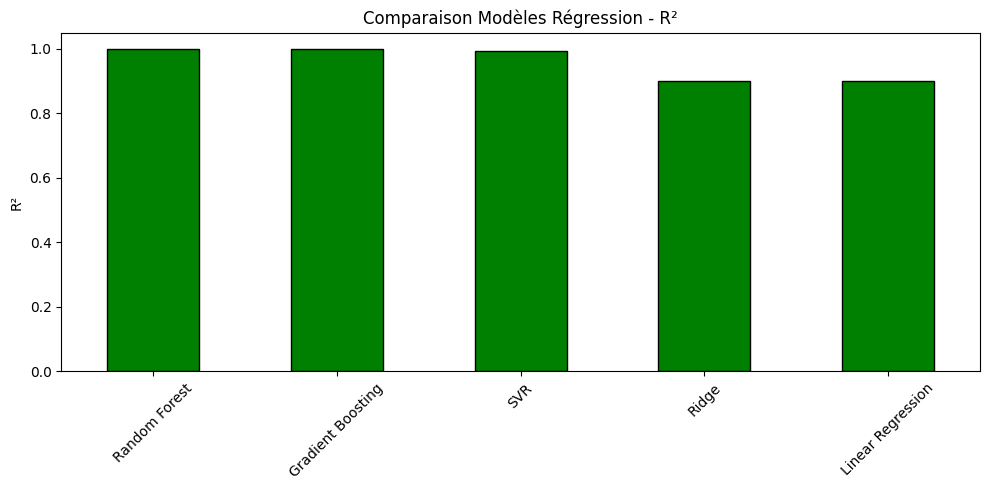

In [12]:
df_reg = pd.DataFrame(resultats_reg).T.sort_values('R2', ascending=False)
print(df_reg.round(4))

plt.figure(figsize=(10,5))
df_reg['R2'].plot(kind='bar', color='green', edgecolor='black')
plt.title('Comparaison Modèles Régression - R²')
plt.ylabel('R²')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Sauvegarder
joblib.dump(meilleur_modele, '../models/classifier_rf.pkl')
joblib.dump(modeles_reg['Random Forest'], '../models/regressor_rf.pkl')

print("✅ Modèles sauvegardés !")
print("   → models/classifier_rf.pkl")
print("   → models/regressor_rf.pkl")

✅ Modèles sauvegardés !
   → models/classifier_rf.pkl
   → models/regressor_rf.pkl
